# Creating new *unseen-awg* weather generators

The provided datasets described in {ref}`data-download` can be used to create new *unseen-awg* weather generators. Apart from the reforecast-based weather generators that are our main focus, it is also possible to create weather generators based on the ERA5 reanalysis.

## Using Snakemake to configure weather generators

Workflows for creating weather generators from raw reforecast data (or ERA5 data) are specified in the `workflow/` directory. Using the provided data ({ref}`data-download`), it is possible to avoid using raw data and to skip the first preprocessing steps in which data is regridded, aggregated to a daily scale and unified.

Using the [Snakemake](https://snakemake.github.io/) workflow manager, creating a weather generator is as easy as:

```bash
conda activate unseen-awg  # activate conda environment
cd <project base directory>  # navigate to unseen-awg base directory
snakemake  --dry-run --cores 1 --configfile configs/weather_generators/reforecasts.yaml
```

This loads the configuration file `configs/weather_generators/reforecasts.yaml` that specifies the weather generator's parameters and produces:
- a weather generator instance
- a small artificial weather dataset generated with the instance
- a tuning run to find ideal values for some of *unseen-awg*'s parameters
- and if necessary, it also generates a post-processed dataset of impact-relevant variables (e.g., including bias correction). 

Adding the `--dry-run` flag allows testing the command without actually producing output, while `--cores 1` indicates that a single core should be used (which is justified here, given it's a dry run). If other outputs are desired, one can vary the configuration file or adjust the `all` rule defined in `workflow/Snakefile`.

### Configuration files

We collected configurations for different weather generator setups in `configs/weather_generators/`. In our study, we use:
- `configs/weather_generators/reforecasts.yaml`
- `configs/weather_generators/reforecasts_no_bias_correction.yaml`
- `configs/weather_generators/era5.yaml`

These `.yaml` files specify parameter values for all necessary preprocessing steps, some of which are described in more detail in {ref}`preprocessing`.

Parameters for the rules that define how to preprocess raw data cannot be changed when working with the provided preprocessed datasets ({ref}`data-download`):
- `preprocess_era5_single`
- `preprocess_circulation_era5`
- `preprocess_impact_variables_era5`
- `preprocess_circulation_reforecasts`
- `preprocess_impact_variables_reforecasts`

If the downloaded data is stored using the correct paths (described in {ref}`data-download`), Snakemake will recognize it as the output of preprocessing rules and skip the early steps of the pipeline.

### A note on resource demands

The Snakemake workflow is computationally expensive, especially if the large reforecast dataset is used. While we tried to keep requirements manageable, creating the full *unseen-awg* weather generator will most likely only be possible on HPC systems, given the demands for disk space, memory and compute. Running smaller test cases (e.g., ERA5-based *unseen-awg* weather generators) should also be possible on personal devices.

Specifying resources (memory, CPU cores, runtime, etc.) on a per-rule basis is possible, and Snakemake also allows creating system-specific profiles. The `resources` section of each Snakemake rule defined in `workflow/rules` will likely have to be adapted to the system the workflow is executed with. We used the `snakemake-executor-plugin-slurm`, which allows Snakemake to execute rules as jobs on a Slurm cluster and created a profile that is adapted to the requirements of our system (not included).

### Visualizing the Snakemake workflow
The command
```bash
snakemake --configfile configs/weather_generators/reforecasts.yaml --rulegraph | dot -Tpng > rulegraph.png
```
can be used to create a helpful visualization of the rules being executed for the given configuration file (in this case `configs/weather_generators/reforecasts.yaml`) and the current state of the `Snakefile`.

The resulting rule graph shows how Snakemake produces an *unseen-awg* instance, generates a test simulation with it, performs a tuning run for some of its parameters, and prepares a bias-corrected dataset of impact-relevant variables:

![Rulegraph of the Snakemake workflow for reforecasts.yaml](images/rulegraph.png)

The rulegraph includes the "raw-data preprocessing rules" that will not be executed if the archived data is used properly. Without bias correction and with a smaller set of targeted outputs, the corresponding graph is much simpler. 

(preprocessing)=
## Preprocessing details and motivation

Two main lines of work are being executed in the Snakemake pipeline:
- if necessary, impact-relevant variables are bias corrected. To do so, biases are computed, merged, and a Zarr store with corrected data is produced. 
- the atmospheric circulation variables are brought into a shape that allows parallelizing similarity computations efficiently.

`rechunk_ds` is a helper rule that rechunks a Zarr store. For some operations (e.g., computing biases), it is far more efficient to have the entire temporal extent in a single chunk and instead split along a spatial dimension, while for others (e.g., computing similarities) it is more efficient to have the full spatial extent in the same chunk but to split along the time dimension. By default, the archived datasets use the latter chunking option.

Below, we explain the preprocessing steps necessary for computing similarities efficiently in more detail.

In [15]:
import os

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import yaml


In [16]:
single_forecast = xr.open_dataset
with open("../../configs/paths.yaml") as file:
    paths = yaml.safe_load(file)["paths"]

path_circulation_ds = os.path.join(
    paths["dir_preprocessed_datasets"],
    "preprocessed_circulation_reforecasts/combined_5e06172f.zarr",
)

path_restructured = os.path.join(
    paths["dir_preprocessed_datasets"],
    "preprocessed_circulation_reforecasts/restructured_5e06172f_f40e9460.nc",
)

path_dayofyear_year = os.path.join(
    paths["dir_preprocessed_datasets"],
    "preprocessed_circulation_reforecasts/data_year_dayofyear_5e06172f_f40e9460.zarr",
)


path_circulation_ds_era5 = os.path.join(
    paths["dir_preprocessed_datasets"],
    "preprocessed_circulation_era5/combined_f3d1f2f7.zarr",
)


### From initiazlization time and lead time to valid time and sample

After the initial preprocessing steps, the atmospheric circulation dataset has temporal dimensions `lead_time` and `init_time`, i.e., forecast lead time and initialization time:

In [17]:
ds_combined = xr.open_zarr(path_circulation_ds)
ds_combined.dims

FrozenMappingWarningOnValuesAccess({'ensemble_member': 11, 'init_time': 2560, 'lead_time': 46, 'latitude': 18, 'longitude': 49})

The data is spaced unevenly along the `init_time` dimension in intervals of three, four, or less days, because ECMWF ran reforecasts twice weekly in the IFS configuration we downloaded data for.

We want to compute similarities between atmospheric states with similar dates, and in this case we're interested in the *valid time*, i.e., the actual time the forecast making predictions for. It can be computed using *init_time* + *lead_time*.

Efficiently parallelizing the similarity computations therefore would require having `valid_time` as a dimension.

In [18]:
ds_combined = ds_combined.assign_coords(
    valid_time=ds_combined.init_time + ds_combined.lead_time
)
unique_valid_times = np.unique(ds_combined.valid_time)

vt_min = np.datetime64("2010-01-01", "ns")
vt_max = np.datetime64("2010-02-01", "ns")

range_vt = np.arange(vt_min, vt_max, np.timedelta64(1, "D"))

In [19]:
contains_data = xr.DataArray(
    np.full((len(ds_combined.lead_time), len(range_vt)), fill_value=False, dtype=bool),
    coords={"lead_time": ds_combined.lead_time, "valid_time": range_vt},
)

for lt in ds_combined.lead_time:
    for j, vt in enumerate(range_vt):
        contains_data.loc[{"lead_time": lt, "valid_time": vt}] = np.isin(
            vt, ds_combined.valid_time.sel(lead_time=lt)
        )
contains_data = contains_data.assign_coords(
    lead_time=contains_data.lead_time / np.timedelta64(1, "D")
)
contains_data.drop_attrs()

<xarray.DataArray (lead_time: 46, valid_time: 31)> Size: 1kB
array([[ True, False, False, ...,  True, False, False],
       [False,  True, False, ..., False,  True, False],
       [False, False,  True, ..., False, False,  True],
       ...,
       [False,  True, False, ..., False,  True, False],
       [False, False,  True, ..., False, False,  True],
       [False, False, False, ..., False, False, False]])
Coordinates:
  * lead_time   (lead_time) float64 368B 0.0 1.0 2.0 3.0 ... 42.0 43.0 44.0 45.0
  * valid_time  (valid_time) datetime64[ns] 248B 2010-01-01 ... 2010-01-31

If we would naively use `valid_time` and `lead_time` as coordinates, this would lead to a strongly inflated dataset with a lot of missing data:

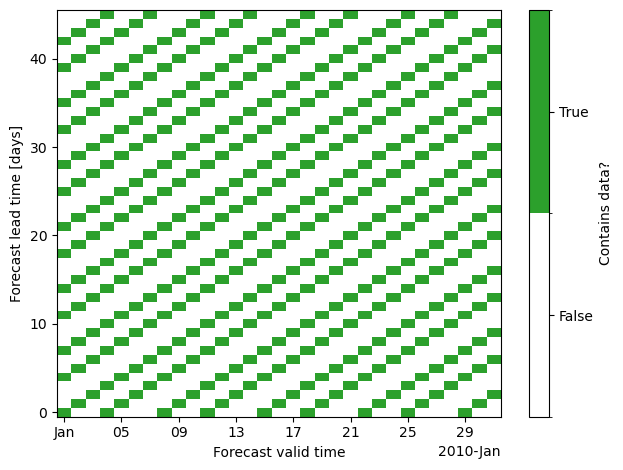

In [20]:
# Create a discrete colormap for binary data
cmap = mcolors.ListedColormap(["#ffffff", "#2ca02c"])  # Red=False, Green=True
bounds = [0, 0.5, 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots()
im = contains_data.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=True,
    cbar_kwargs={
        "label": "Contains data?",
        "ticks": [0.25, 0.75],
    },
)

cbar = im.colorbar
cbar.ax.set_yticklabels(["False", "True"])

plt.xlabel("Forecast valid time")
plt.ylabel("Forecast lead time [days]")
plt.tight_layout()
plt.show()


The reason is that forecasts aren't initialized on all days, instead the dataset has gaps between initializations.

The strategy we're implementing instead (in the `merge_restructure_ds` rule) instead uses `valid_time` as one of the dimensions and introduces a new dimension `sample` that we populate with all forecasts for the same `valid_time`, i.e. all cells that do contain data along each vertical line in the plot above. We compute a look-up table to extract `lead_time` and `init_time` from `valid_time` and `sample`.

In [21]:
ds_restructured = xr.open_dataset(path_restructured)
ds_restructured.drop_attrs()

<xarray.Dataset> Size: 16GB
Dimensions:              (valid_time: 7430, sample: 27, ensemble_member: 11,
                          lag: 1, latitude: 18, longitude: 49)
Coordinates:
  * valid_time           (valid_time) datetime64[ns] 59kB 2003-06-29 ... 2023...
  * sample               (sample) int64 216B 0 1 2 3 4 5 6 ... 21 22 23 24 25 26
  * ensemble_member      (ensemble_member) int64 88B 0 1 2 3 4 5 6 7 8 9 10
  * lag                  (lag) timedelta64[ns] 8B 00:00:00
  * latitude             (latitude) float64 144B 30.0 32.5 35.0 ... 70.0 72.5
  * longitude            (longitude) float64 392B -80.0 -77.5 ... 37.5 40.0
    pressure             int64 8B ...
Data variables:
    geopotential_height  (valid_time, sample, ensemble_member, lag, latitude, longitude) float64 16GB ...
    init_time            (valid_time, sample) datetime64[ns] 2MB ...

Repeating the plot above with the new dataset and dimensions `(valid_time, sample)`, we see that we can represent the data much more compactly.

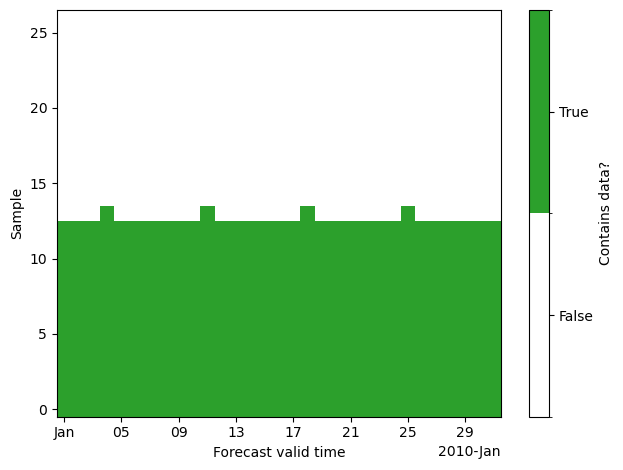

In [22]:
# Create a discrete colormap for binary data
cmap = mcolors.ListedColormap(["#ffffff", "#2ca02c"])  # Red=False, Green=True
bounds = [0, 0.5, 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots()
im = (
    (~np.isnat(ds_restructured.init_time.sel(valid_time=range_vt)))
    .transpose()
    .plot(
        ax=ax,
        cmap=cmap,
        norm=norm,
        add_colorbar=True,
        cbar_kwargs={
            "label": "Contains data?",
            "ticks": [0.25, 0.75],
        },
    )
)


cbar = im.colorbar
cbar.ax.set_yticklabels(["False", "True"])

plt.title("")
plt.xlabel("Forecast valid time")
plt.ylabel("Sample")
plt.tight_layout()
plt.show()


The size of the `sample` dimension is chosen as the maximum number of states with same `valid_time`. This is already smaller than the lead_time dimension:

In [23]:
print("Length lead_time dimension:", len(ds_combined.lead_time))
print("Length sample dimension:", len(ds_restructured.sample))

Length lead_time dimension: 46
Length sample dimension: 27


In our dataset, everything larger than `sample == 13` contains almost exclusively missing data. Therefore, we usually restrict the data to samples `0` to `13` by setting `n_samples: 14` in the corresponding configuration file. This is especially important as the computational demand for precomputing similarities scales quadratically with the number of included states.

### Splitting valid time dimension into year and dayofyear

What we want to compute is similarities between states with a similar *day of year* of `valid_time`, not with a similar `valid_time` itself.

The next step (rule `to_year_dayofyear_format`) therefore consists of splitting the `valid_time`dimension into two separate dimensions `year` and `dayofyear`. We chunk the dataset along the `dayofyear` dimension to allow memory-efficient computations:

In [24]:
xr.open_zarr(path_dayofyear_year)["geopotential_height"].drop_attrs()

<xarray.DataArray 'geopotential_height' (dayofyear: 366, year: 21, sample: 27,
                                         ensemble_member: 11, lag: 1,
                                         latitude: 18, longitude: 49)> Size: 16GB
dask.array<open_dataset-geopotential_height, shape=(366, 21, 27, 11, 1, 18, 49), dtype=float64, chunksize=(1, 21, 27, 11, 1, 18, 49), chunktype=numpy.ndarray>
Coordinates:
  * dayofyear        (dayofyear) int64 3kB 1 2 3 4 5 6 ... 362 363 364 365 366
  * year             (year) int64 168B 2003 2004 2005 2006 ... 2021 2022 2023
  * sample           (sample) int64 216B 0 1 2 3 4 5 6 ... 20 21 22 23 24 25 26
  * ensemble_member  (ensemble_member) int64 88B 0 1 2 3 4 5 6 7 8 9 10
  * lag              (lag) timedelta64[ns] 8B 00:00:00
  * latitude         (latitude) float64 144B 30.0 32.5 35.0 ... 67.5 70.0 72.5
  * longitude        (longitude) float64 392B -80.0 -77.5 -75.0 ... 37.5 40.0

### A note on the provided ERA5 datasets

In order to make it easier to use ERA5 data within the *unseen-awg* framework, we cast it to the same format as the reforecast data. This means, that we introduce "dummy dimensions" `init_time` and `ensemble_member` with size 1 and convert the ERA5 time axis to the `lead_time` with respect to the first included time step:

In [25]:
xr.open_dataarray(path_circulation_ds_era5).drop_attrs()

<xarray.DataArray 'geopotential_height' (ensemble_member: 1, init_time: 1,
                                         lead_time: 7670, latitude: 18,
                                         longitude: 49)> Size: 27MB
[6764940 values with dtype=float32]
Coordinates:
  * ensemble_member  (ensemble_member) int64 8B 0
  * init_time        (init_time) datetime64[ns] 8B 2003-01-01
  * lead_time        (lead_time) timedelta64[ns] 61kB 0 days ... 7669 days
  * latitude         (latitude) float64 144B 30.0 32.5 35.0 ... 67.5 70.0 72.5
  * longitude        (longitude) float64 392B -80.0 -77.5 -75.0 ... 37.5 40.0
    pressure         int64 8B ...

The rest of the processing pipeline follows what is done for reforecast data.